# Задача кластеризации

## Загрузка и первичная подготовка данных

### 1) Загрузка

In [143]:
# Расскомментировать при необходимости подгрузить в Colab .csv файл датасета
# from google.colab import files
# uploaded = files.upload()

In [144]:
import pandas as pd
df = pd.read_csv("wine_quality.csv")
# df.head() # Проверка загрузки датасета


Датасет содержит список образцов вина, и значения признаков, описывающих химические характеристики каждого образца.
Переменная quality задаёт оценку качества вина и будет использоваться для последующего анализа результатов кластеризации.

### 2) Разделяем признаки и целевую переменную.
Так как решается задача обучения без учителя, целевая переменная не должна участвовать в процессе обучения моделей.
Однако она сохраняется отдельно, чтобы после выполнения кластеризации можно было сравнить полученные кластеры с истинными оценками качества вина.

In [145]:
X = df.drop(columns=["quality"])
y = df["quality"]

print(X.shape)
print("Classes:", sorted(y.unique()))

(6497, 12)
Classes: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


### 3) Кодирование категориального признака

In [146]:
X["type"] = X["type"].map({"red": 0, "white": 1})
# X.dtypes # Проверка типов

Алгоритмы кластеризации работают только с числовыми данными, поэтому категориальный признак типа вина (красное, белое) необходимо преобразовать.

Так как данный признак является бинарным, используется простое числовое кодирование, которое не искажает структуру данных и не увеличивает размерность пространства признаков.

### 4) Масштабирование признаков

In [147]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Признаки в исходных данных имеют различные масштабы измерений (концентрации, проценты, плотность).

Без масштабирования признаки с большими значениями могли бы доминировать над признаками с малыми значениями, что негативно сказалось бы на качестве кластеризации. По этой причине необходимо привести данные к нулевому среднему и единичному стандартному отклонению.

## Применение алгоритмов кластеризации

In [148]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=len(y.unique()), random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [149]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)


In [150]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=len(y.unique()))
agg_labels = agg.fit_predict(X_scaled)

## Визуализация результатов

In [151]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.3174498  0.21072897]
Total explained variance: 0.5281787645842968


Для наглядного представления результатов кластеризации данные проецируются в двумерное пространство с помощью метода главных компонент (PCA).

PCA позволяет сохранить основную структуру данных, уменьшив их размерность, что делает возможной визуализацию.

! Важно отметить, что PCA используется только для визуального анализа, а сами алгоритмы кластеризации обучаются в полном пространстве признаков !

In [152]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
print("KMeans ARI:", adjusted_rand_score(y, kmeans_labels))
print("KMeans NMI:", normalized_mutual_info_score(y, kmeans_labels))

print("DBSCAN ARI:", adjusted_rand_score(y, dbscan_labels))
print("Agglomerative ARI:", adjusted_rand_score(y, agg_labels))

KMeans ARI: 0.028571159302038483
KMeans NMI: 0.06074100912136338
DBSCAN ARI: 0.0026220580397583303
Agglomerative ARI: 0.026591980403302733


**Adjusted Rand Index (ARI)**
Этот метод показывает, насколько совпадают кластеры, найденные алгоритмом, с истинными метками (y).
Диапазон: [-1, 1].
1 → полное совпадение кластеров с истинными метками
0 → совпадение на уровне случайного распределения
<0 → хуже случайного

KMeans ARI ≈ 0.03
Agglomerative ARI ≈ 0.027
DBSCAN ARI ≈ 0.003

**Normalized Mutual Information (NMI)**
Этот метод измеряет взаимную информацию между истинными и найденными кластерами, нормированную от 0 до 1.

0 → кластеры не связаны с истинными метками
1 → полное совпадение

KMeans NMI ≈ 0.061 → очень слабая связь с истинными метками

Можно сделать вывод: кластеры почти не соответствуют истинным классам качества! Кластеризация практически не отражает структуру исходных данных с точки зрения классов!

In [153]:
import seaborn as sns

vis_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "quality": y.values,
    "KMeans": kmeans_labels,
    "DBSCAN": dbscan_labels,
    "Agglomerative": agg_labels
})


Контурная визуализация плотности с использованием PCA по двум главным компонентам. Цвета показывают реальные оценки качества вина:

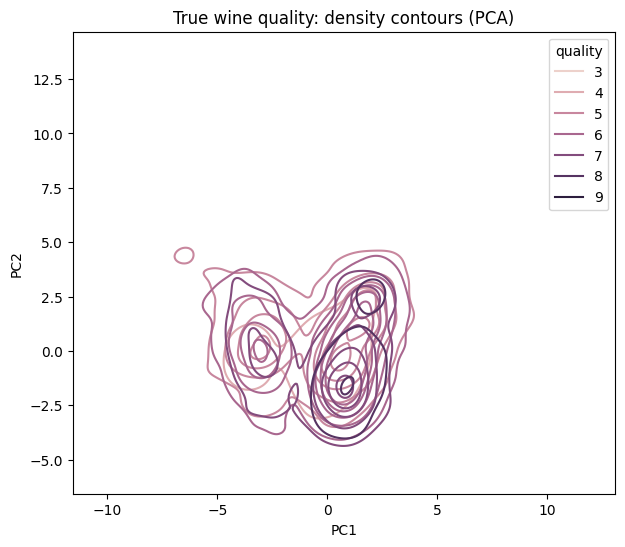

In [154]:
plt.figure(figsize=(7, 6))
sns.kdeplot(
    data=vis_df,
    x="PC1",
    y="PC2",
    hue="quality",
    levels=6,
    fill=False
)
plt.title("True wine quality: density contours (PCA)")
plt.show()


Результаты кластеризации методом KMeans. Кластеры практически не соответствуют истинным классам качества, подтверждая низкие значения ARI и NMI.

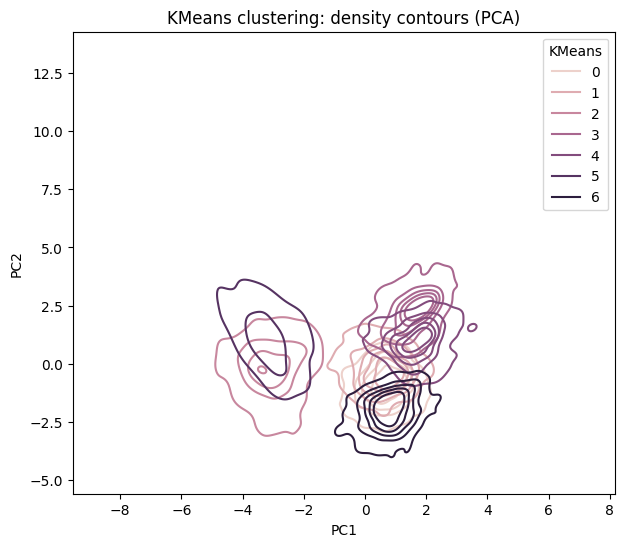

In [155]:
plt.figure(figsize=(7, 6))
sns.kdeplot(
    data=vis_df,
    x="PC1",
    y="PC2",
    hue="KMeans",
    levels=6,
    fill=False
)
plt.title("KMeans clustering: density contours (PCA)")
plt.show()


Кластеризация методом DBSCAN. Большинство точек попадают в шум или плохо разделяются на кластеры. Этот метод на данном датасете почти не работает.

/tmp/ipython-input-335818422.py:17: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


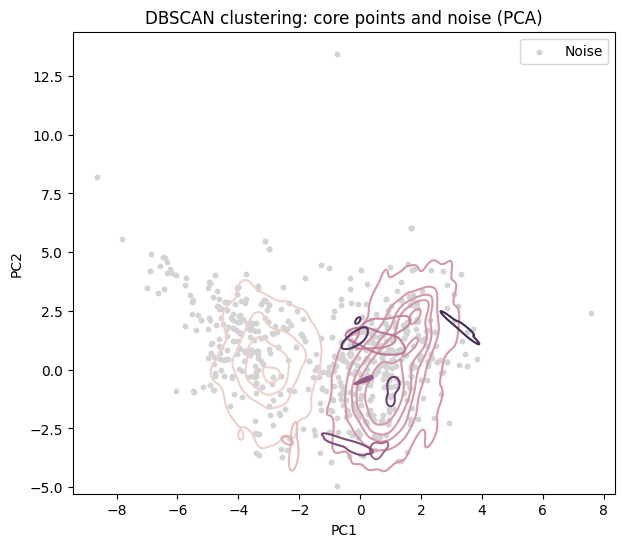

In [156]:
dbscan_core = vis_df[vis_df["DBSCAN"] != -1]
dbscan_noise = vis_df[vis_df["DBSCAN"] == -1]

plt.figure(figsize=(7, 6))

# Шум — серый
plt.scatter(
    dbscan_noise["PC1"],
    dbscan_noise["PC2"],
    c="lightgray",
    s=10,
    label="Noise"
)

sns.kdeplot(
    data=dbscan_core,
    x="PC1",
    y="PC2",
    hue="DBSCAN",
    levels=6,
    fill=False
)

plt.title("DBSCAN clustering: core points and noise (PCA)")
plt.legend()
plt.show()


Результаты иерархической кластеризации (Agglomerative). Визуально контуры схожи с аналогичными контурами полученными методом KMeans. И также, как и у KMeans заметно не соответствие истинным классам качества.

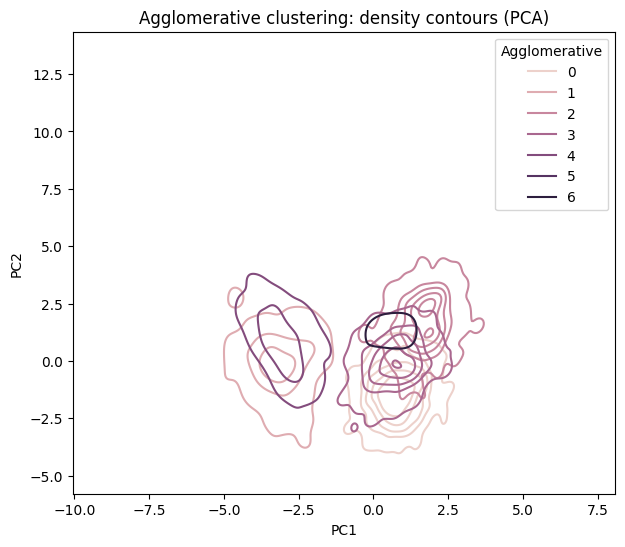

In [157]:
plt.figure(figsize=(7, 6))
sns.kdeplot(
    data=vis_df,
    x="PC1",
    y="PC2",
    hue="Agglomerative",
    levels=6,
    fill=False
)
plt.title("Agglomerative clustering: density contours (PCA)")
plt.show()


Следует отметить, что номера кластеров, получаемые алгоритмами кластеризации, являются условными и не имеют прямого соответствия с истинными значениями качества вина. Кроме того, нумерация кластеров может отличаться для различных алгоритмов. Поэтому при визуальном анализе результаты интерпретируются с точки зрения формы и взаимного расположения кластеров, а сравнение с истинными метками проводится с использованием специальных метрик согласованности.

Рассмотрим еще более наглядный вариант демонстрации того, что изучаемый датасет очень плохо кластеризуется (разбиение на кластеры не соответствует классам задачи классификации). Выделить один конкретный класс quality - 6 (самый многочисленный класс качества). Покажем результаты кластеризации по этому одному классу и заметим, что методы либо бьют его на отдельные кластеры, либо, в случае DBSCAN, все данные попадают в "шум".

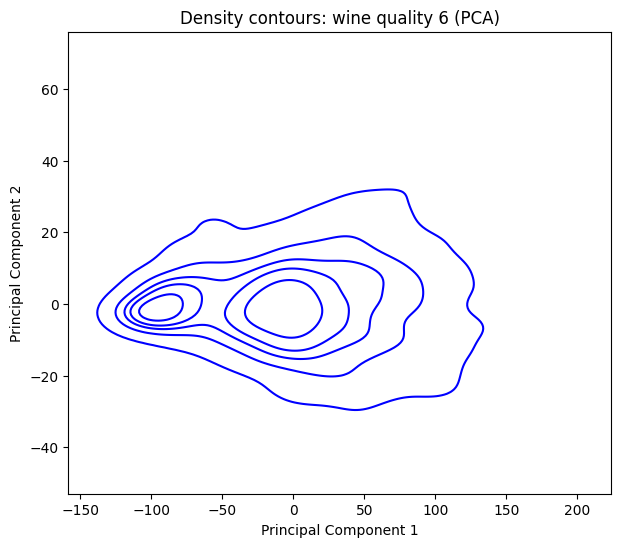

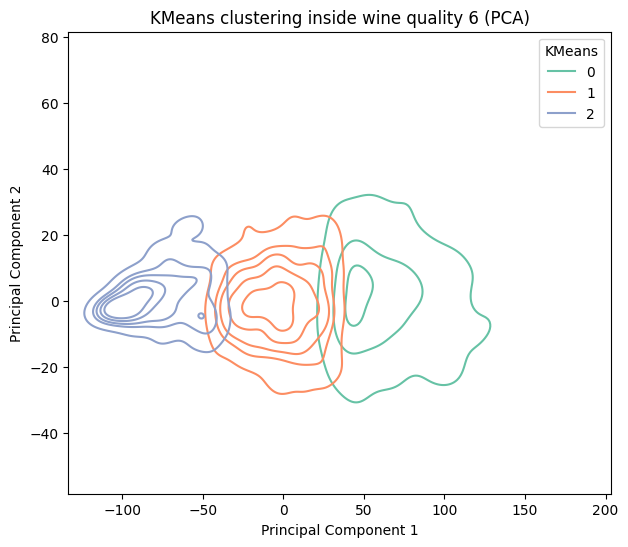

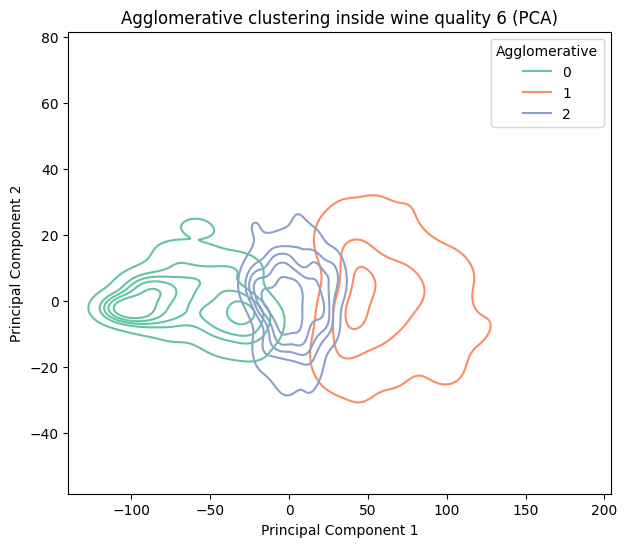

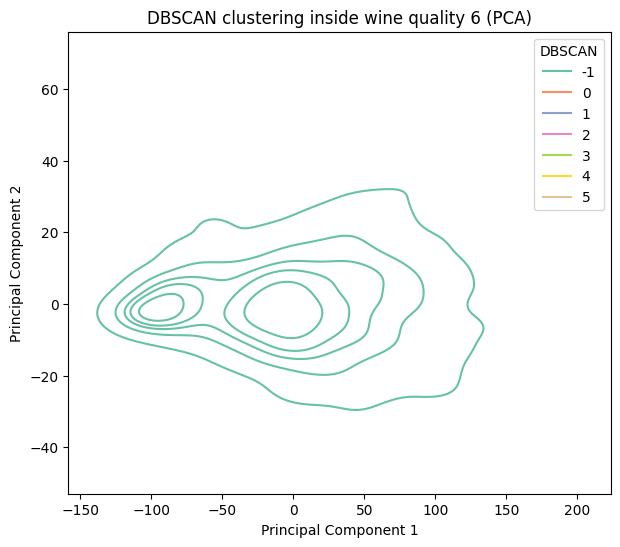

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

selected_quality = 6
class_df = vis_df[vis_df['quality'] == selected_quality]
class_X = X[y == selected_quality]
class_y = y[y == selected_quality]

pca = PCA(n_components=2)
class_pca = pca.fit_transform(class_X)
class_vis_df = class_df.copy()
class_vis_df['PC1'] = class_pca[:, 0]
class_vis_df['PC2'] = class_pca[:, 1]

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

kmeans = KMeans(n_clusters=3, random_state=42)
agglo = AgglomerativeClustering(n_clusters=3)
dbscan = DBSCAN(eps=0.5, min_samples=5)

class_vis_df['KMeans'] = kmeans.fit_predict(class_X)
class_vis_df['Agglomerative'] = agglo.fit_predict(class_X)
class_vis_df['DBSCAN'] = dbscan.fit_predict(class_X)

algorithms = ['KMeans', 'Agglomerative', 'DBSCAN']

plt.figure(figsize=(7,6))
sns.kdeplot(
    data=class_vis_df,
    x="PC1",
    y="PC2",
    levels=6,
    fill=False,
    color='blue'
)
plt.title(f"Density contours: wine quality {selected_quality} (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

for algo in algorithms:
    plt.figure(figsize=(7,6))
    sns.kdeplot(
        data=class_vis_df,
        x="PC1",
        y="PC2",
        hue=algo,
        levels=6,
        fill=False,
        palette='Set2',
        warn_singular=False
    )
    plt.title(f"{algo} clustering inside wine quality {selected_quality} (PCA)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()


## Вывод

Алгоритмы кластеризации практически не смогли выделить классы качества вина.

Основная причина — большинство признаков слабо связаны с quality (корреляция выше 0.5 только у 4 из 12 признаков, по данным, который были получены в ходе ДЗ №3).

Следовательно, стандартные алгоритмы кластеризации на этих данных не подходят напрямую для предсказания качества вина.